In [1]:
# 数据库连接
import pymysql
# 数据处理
import pandas as pd
# 数值计算
import numpy as np
# 数据可视化
import matplotlib.pyplot as plt
# 机器学习模型
from sklearn.linear_model import Ridge, Lasso, LinearRegression
# 模型评估指标
from sklearn.metrics import r2_score
# 数据集划分
from sklearn.model_selection import train_test_split
# 数据标准化
from sklearn.preprocessing import StandardScaler


In [2]:
#导入中文模块
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False
# 连接MySQL数据库
conn = pymysql.connect(
    host='localhost',      # 数据库地址
    user='root',           # 用户名
    password='20040915',   # 密码
    database='lndx',       # 数据库名
    charset='utf8mb4'      # 字符编码
)
# 从course表读取数据
df = pd.read_sql("select * from course", conn)
conn.close()  # 关闭连接
print(df.head(5))  # 查看前5行数据
# 准备特征和目标变量
X = df[['ctime']]  # 特征：课时数（二维）
y = df['cost']     # 目标：课程费用（一维）
print(X.head(5))  # 查看前5行课时数
print(y.head(5))  # 查看前5行费用

     cnum        enum cname  ctime              cstart                cend  \
0  000001  2022000011    网购     39 2025-01-09 16:20:00 2026-03-29 20:20:00   
1  000002  2022000008   八段锦     37 2025-01-04 19:40:00 2026-02-21 09:20:00   
2  000003  2022000009    烹饪     37 2025-01-14 07:26:40 2026-01-05 15:06:40   
3  000004  2022000006    网购     36 2025-01-09 08:00:00 2026-01-15 02:53:20   
4  000005  2022000019   八段锦     37 2025-02-19 10:06:40 2026-01-10 03:26:40   

   cost  
0  2425  
1  2127  
2  2136  
3  2038  
4  2081  
   ctime
0     39
1     37
2     37
3     36
4     37
0    2425
1    2127
2    2136
3    2038
4    2081
Name: cost, dtype: int64


C:\Users\17006\AppData\Local\Temp\ipykernel_32796\4030160062.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql("select * from course", conn)


In [3]:
#划分数据集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
#对数据进行标准化
scaler_X = StandardScaler()
scaler_y = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)
# 重要：将y_train和y_test转换为二维数组
y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).ravel()
y_test_scaled = scaler_y.transform(y_test.values.reshape(-1, 1)).ravel()

C:\Users\17006\PycharmProjects\PythonProject2\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


0.9976064020418155


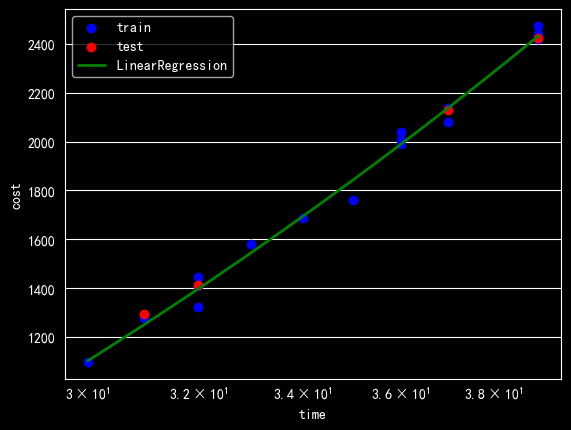

In [4]:
#线性回归模型
lr=LinearRegression()
lr.fit(X_train_scaled,y_train_scaled)#训练模型
y_pred_scaled=lr.predict(X_test_scaled)#标准化后的预测值
y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).ravel()#恢复之后的预测值
#计算R**2
r2 = r2_score(y_test, y_pred)
print(r2)
# 绘制线性回归模型的scatter和plot
plt.figure()  # 创建画布
# 绘制训练集和测试集的散点图
plt.scatter(X_train, y_train, c='blue', label='train')  # 训练集（蓝色）
plt.scatter(X_test, y_test, c='red', label='test')      # 测试集（红色）
# 生成用于绘制回归线的数据点
X_line = np.linspace(X_train.min(), X_train.max(), 100).reshape(-1, 1)  # 生成100个等间隔的课时数
X_line_scaled = scaler_X.transform(X_line)  # 对生成的X数据进行标准化
y_line_scaled = lr.predict(X_line_scaled)   # 用模型预测标准化后的y值
y_line = scaler_y.inverse_transform(y_line_scaled.reshape(-1, 1)).ravel()  # 将预测值还原为原始尺度
# 绘制回归线
plt.plot(X_line, y_line, color='green', linewidth=2, label='LinearRegression')  # 绿色回归线
plt.xscale('log')      # x轴设为对数刻度
plt.xlabel('time')     # x轴标签：课时数
plt.ylabel('cost')     # y轴标签：费用
plt.grid(True)         # 显示网格
plt.legend()           # 显示图例
plt.show()             # 显示图表

In [5]:
#列举部分alpha
ridge_alphas = [0.001, 0.01, 0.1, 1, 10, 100, 1000]
lasso_alphas = [0.0001, 0.001, 0.01, 0.1, 1, 10, 100]
#储存不同alpha下lasso回归和ridge回归的结果
r_result=[]
l_result=[]

#求出每个alpha对应的ridge回归的R**2
for alphas in ridge_alphas:
    ridge = Ridge(alpha=alphas)
    ridge.fit(X_train_scaled, y_train_scaled)
    r_result.append(ridge.score(X_test_scaled, y_test_scaled))

#求出每个alpha对应的lasso回归的R**2
for alphas in lasso_alphas:
    lasso = Lasso(alpha=alphas)
    lasso.fit(X_train_scaled, y_train_scaled)
    l_result.append(lasso.score(X_test_scaled, y_test_scaled))
#输出结果
print(r_result)
print(l_result)

[0.9976116611133412, 0.9976585832507728, 0.9980877476328671, 0.9988159600838211, 0.8699174368034429, 0.26599866354114576, 0.03216878800226364]
[0.9976148487254812, 0.9976898866523134, 0.9983430255308617, 0.9951503753389752, -0.0003198562085862111, -0.0003198562085862111, -0.0003198562085862111]


In [6]:
# 找到最佳 alpha 值
best_ridge_alpha = ridge_alphas[np.argmax(r_result)]
best_ridge_score = max(r_result)
best_lasso_alpha = lasso_alphas[np.argmax(l_result)]
best_lasso_score = max(l_result)

Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], 

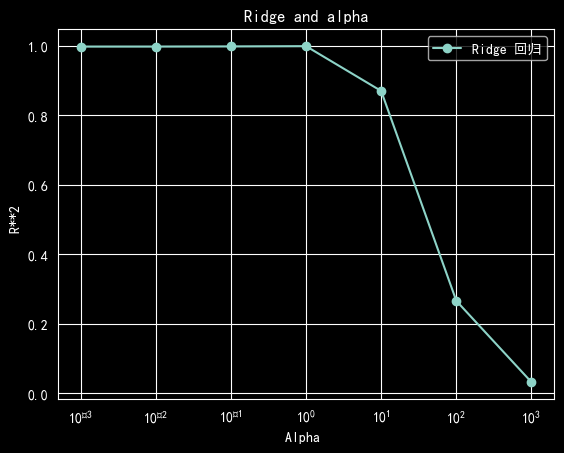

In [7]:
# 绘制 ridge 回归不同 alpha 值的性能
plt.plot(ridge_alphas, r_result, 'o-', label='Ridge 回归')  # 'o-'表示带圆点的折线图
plt.xscale('log')      # x轴（alpha值）采用对数刻度，因为alpha跨度大
plt.xlabel('Alpha ')   # x轴标签：正则化强度参数
plt.ylabel('R**2 ')    # y轴标签：拟合优度（越接近1拟合越好）
plt.title('Ridge and alpha')  # 图表标题
plt.grid(True)         # 显示网格，便于查看数值
plt.legend()           # 显示图例
plt.show()             # 显示图表


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], 

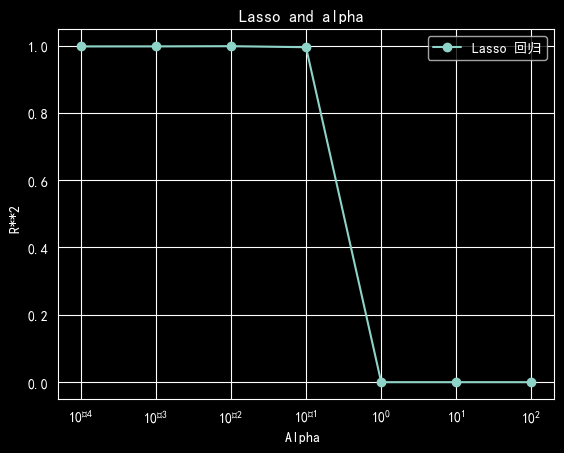

In [8]:
# 绘制 Lasso 回归不同 alpha 值的性能
plt.plot(lasso_alphas, l_result, 'o-', label='Lasso 回归')  # 'o-'带圆点折线图，显示alpha与R²关系
plt.xscale('log')      # x轴对数刻度（alpha值跨度大，对数刻度更清晰）
plt.xlabel('Alpha ')   # x轴：正则化参数（越大正则化越强）
plt.ylabel('R**2 ')    # y轴：拟合优度（评估模型性能）
plt.title('Lasso and alpha ')  # 图表标题
plt.grid(True)         # 显示网格线
plt.legend()           # 显示图例
plt.show()             # 渲染显示图表